In [87]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random

In [88]:
headers = {
    "User-Agent": "Mozilla/5.0"
}

In [89]:
url = "https://www.incredibleindia.gov.in/en"

In [90]:
response = requests.get(url, headers=headers)

In [91]:
response

<Response [200]>

In [92]:
soup = BeautifulSoup(response.text, "html.parser")

In [93]:
links = []

for a in soup.find_all("a", href=True):

    link = a["href"]

    if "/en/" in link:

        if link.startswith("http"):
            full_link = link
        else:
            full_link = "https://www.incredibleindia.gov.in" + link

        links.append(full_link)

In [94]:
links = list(set(links))

In [95]:
len(links)

428

In [96]:
print(links[:5])

['https://www.incredibleindia.gov.in/en/uttarakhand/gangotri', 'https://www.incredibleindia.gov.in/en/andhra-pradesh/kakinada', 'https://www.incredibleindia.gov.in/en/telangana/threading-the-wires-of-tradition-silver-filigree-of-karimnagar', 'https://www.incredibleindia.gov.in/en/tamil-nadu/kanchipuram', 'https://www.incredibleindia.gov.in/en/tamil-nadu/ooty']


In [97]:
Place_Name = []
State = []
City = []
Category = []

In [98]:
for url in links[:5]:
    print(url)

https://www.incredibleindia.gov.in/en/uttarakhand/gangotri
https://www.incredibleindia.gov.in/en/andhra-pradesh/kakinada
https://www.incredibleindia.gov.in/en/telangana/threading-the-wires-of-tradition-silver-filigree-of-karimnagar
https://www.incredibleindia.gov.in/en/tamil-nadu/kanchipuram
https://www.incredibleindia.gov.in/en/tamil-nadu/ooty


In [99]:
Place_Name = []
State = []
City = []
Category = []

for url in links:

    parts = url.split("/")

    place = parts[-1].replace("-", " ").title()
    Place_Name.append(place)

    state = parts[4].replace("-", " ").title()
    State.append(state)

    if len(parts) > 6:
        city = parts[5].replace("-", " ").title()
    else:
        city = "NA"

    City.append(city)

    cat = soup.find("span", class_="category")

    if cat:
        Category.append(cat.text.strip())
    else:
        Category.append("NA")

In [100]:
df = pd.DataFrame({
    "Place_Name": Place_Name,
    "State": State,
    "City": City,
    "Category": Category
})

In [101]:
df

,Place_Name,State,City,Category
0,Gangotri,Uttarakhand,NA,NA
1,Kakinada,Andhra Pradesh,NA,NA
2,Threading The Wires Of Tradition Silver Filigr...,Telangana,NA,NA
3,Kanchipuram,Tamil Nadu,NA,NA
4,Ooty,Tamil Nadu,NA,NA
...,...,...,...,...
423,Khangchendzonga National Park,Sikkim,Pelling,NA
424,Karnataka,Karnataka,NA,NA
425,Muga Silk Weaving A Golden Tradition,Assam,NA,NA
426,Puri,Odisha,NA,NA


In [102]:
df.tail(30)

,Place_Name,State,City,Category
398,Dirang,Arunachal Pradesh,NA,NA
399,Mount Manipur National Park,Andaman And Nicobar Islands,Sri Vijaya Puram,NA
400,Manali,Himachal Pradesh,NA,NA
401,Varkala,Kerala,NA,NA
402,Bagalkote,Karnataka,NA,NA
403,Uttarakhand,Uttarakhand,NA,NA
404,Dachigam National Park,Jammu And Kashmir,Srinagar,NA
405,Andhra Pradesh,Andhra Pradesh,NA,NA
406,Diu,Dadra And Nagar Haveli And Daman And Diu,NA,NA
407,Chitrakoot,Uttar Pradesh,NA,NA


In [103]:
df.to_excel("tourist_places.xlsx", index=False)

In [104]:
import os
os.listdir()

[' Student Management System.ipynb',
 ' Student Management System.zip',
 '.anaconda',
 '.conda',
 '.condarc',
 '.continuum',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.matplotlib',
 '.vscode',
 'Advance Stats - Discrete Probability Distributions.ipynb',
 'Advance Stats - Discrete Probability Distributions.zip',
 'advanced stats.ipynb',
 'anaconda3',
 'AppData',
 'Application Data',
 'article.txt',
 'Assignment - Exception Handling  .ipynb',
 'Assignment - Exception Handling  .zip',
 'ATM.ipynb',
 'ATM.zip',
 'CASE STUDY - 2 (Diabetes).ipynb',
 'combined.txt',
 'Contacts',
 'Continuous Probability, Estimates.ipynb',
 'Continuous Probability, Estimates.zip',
 'Cookies',
 'copy_mock.txt',
 'CrossDevice',
 'datetime.csv',
 'datetime.ipynb',
 'datetime.xlsx',
 'ddd.ipynb',
 'dictionary 22.ipynb',
 'dictionary 22.zip',
 'dictionary.ipynb',
 'Documents',
 'Downloads',
 'EDA.ipynb',
 'EDA_project_Laptop price prediction.ipynb',
 'Exception Handling.ipynb',
 'Expense Tracker.ipynb',
 '

In [105]:
from IPython.display import FileLink
FileLink("tourist_places.xlsx")

C:\Users\Nikhitha Kankanala\tourist_places.xlsx

In [106]:
import os
print(os.getcwd())

C:\Users\Nikhitha Kankanala


# Cleaning

In [144]:
# Load the Dataset
import pandas as pd

df = pd.read_excel("C:\\Users\\Nikhitha Kankanala\\tourist_places.xlsx")   

In [145]:
df

,Place_Name,State,City,Category
0,Gangotri,Uttarakhand,NaN,NaN
1,Kakinada,Andhra Pradesh,NaN,NaN
2,Threading The Wires Of Tradition Silver Filigr...,Telangana,NaN,NaN
3,Kanchipuram,Tamil Nadu,NaN,NaN
4,Ooty,Tamil Nadu,NaN,NaN
...,...,...,...,...
423,Khangchendzonga National Park,Sikkim,Pelling,NaN
424,Karnataka,Karnataka,NaN,NaN
425,Muga Silk Weaving A Golden Tradition,Assam,NaN,NaN
426,Puri,Odisha,NaN,NaN


In [146]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 428 entries, 0 to 427
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Place_Name  428 non-null    object 
 1   State       428 non-null    object 
 2   City        138 non-null    object 
 3   Category    0 non-null      float64
dtypes: float64(1), object(3)
memory usage: 13.5+ KB


In [201]:
df.columns

Index(['Place_Name', 'State', 'City', 'Category'], dtype='object')

In [147]:
# Replace NA Strings with Proper Missing Values
df.replace("NA", pd.NA, inplace=True)

In [148]:
# Check missing values.

df.isnull().sum()

Place_Name      0
State           0
City          290
Category      428
dtype: int64

In [149]:
# Fill Missing City Values

df["City"] = df["City"].fillna(df["Place_Name"])

In [150]:
#Check again:

df.isnull().sum()

Place_Name      0
State           0
City            0
Category      428
dtype: int64

In [153]:
# Fill Missing Category
df["Category"] = df["Place_Name"].apply(detect_category)

In [154]:
df["Category"]

0      Tourist Place
1      Tourist Place
2      Tourist Place
3      Tourist Place
4      Tourist Place
           ...      
423         Wildlife
424    Tourist Place
425    Tourist Place
426    Tourist Place
427    Tourist Place
Name: Category, Length: 428, dtype: object

In [155]:
# Now check again:

df.isnull().sum()

Place_Name    0
State         0
City          0
Category      0
dtype: int64

In [156]:
# Remove Duplicate Rows
df = df.drop_duplicates()

In [157]:
df = df.drop_duplicates(subset=["Place_Name","State"])

In [158]:
df

,Place_Name,State,City,Category
0,Gangotri,Uttarakhand,Gangotri,Tourist Place
1,Kakinada,Andhra Pradesh,Kakinada,Tourist Place
2,Threading The Wires Of Tradition Silver Filigr...,Telangana,Threading The Wires Of Tradition Silver Filigr...,Tourist Place
3,Kanchipuram,Tamil Nadu,Kanchipuram,Tourist Place
4,Ooty,Tamil Nadu,Ooty,Tourist Place
...,...,...,...,...
423,Khangchendzonga National Park,Sikkim,Pelling,Wildlife
424,Karnataka,Karnataka,Karnataka,Tourist Place
425,Muga Silk Weaving A Golden Tradition,Assam,Muga Silk Weaving A Golden Tradition,Tourist Place
426,Puri,Odisha,Puri,Tourist Place


In [159]:
# Clean Text Formatting
df["Place_Name"] = df["Place_Name"].str.title()
df["State"] = df["State"].str.title()
df["City"] = df["City"].str.title()

In [160]:
df["Place_Name"]

0                                               Gangotri
1                                               Kakinada
2      Threading The Wires Of Tradition Silver Filigr...
3                                            Kanchipuram
4                                                   Ooty
                             ...                        
423                        Khangchendzonga National Park
424                                            Karnataka
425                 Muga Silk Weaving A Golden Tradition
426                                                 Puri
427                                              Lunglei
Name: Place_Name, Length: 424, dtype: object

In [161]:
df["State"]

0         Uttarakhand
1      Andhra Pradesh
2           Telangana
3          Tamil Nadu
4          Tamil Nadu
            ...      
423            Sikkim
424         Karnataka
425             Assam
426            Odisha
427           Mizoram
Name: State, Length: 424, dtype: object

In [162]:
df["City"]

0                                               Gangotri
1                                               Kakinada
2      Threading The Wires Of Tradition Silver Filigr...
3                                            Kanchipuram
4                                                   Ooty
                             ...                        
423                                              Pelling
424                                            Karnataka
425                 Muga Silk Weaving A Golden Tradition
426                                                 Puri
427                                              Lunglei
Name: City, Length: 424, dtype: object

In [163]:
df["Place_Name"] = df["Place_Name"].str.strip()
df["State"] = df["State"].str.strip()
df["City"] = df["City"].str.strip()

In [164]:
df["Place_Name"]

0                                               Gangotri
1                                               Kakinada
2      Threading The Wires Of Tradition Silver Filigr...
3                                            Kanchipuram
4                                                   Ooty
                             ...                        
423                        Khangchendzonga National Park
424                                            Karnataka
425                 Muga Silk Weaving A Golden Tradition
426                                                 Puri
427                                              Lunglei
Name: Place_Name, Length: 424, dtype: object

In [165]:
df["State"]

0         Uttarakhand
1      Andhra Pradesh
2           Telangana
3          Tamil Nadu
4          Tamil Nadu
            ...      
423            Sikkim
424         Karnataka
425             Assam
426            Odisha
427           Mizoram
Name: State, Length: 424, dtype: object

In [166]:
df["City"]

0                                               Gangotri
1                                               Kakinada
2      Threading The Wires Of Tradition Silver Filigr...
3                                            Kanchipuram
4                                                   Ooty
                             ...                        
423                                              Pelling
424                                            Karnataka
425                 Muga Silk Weaving A Golden Tradition
426                                                 Puri
427                                              Lunglei
Name: City, Length: 424, dtype: object

In [167]:
# Fill Missing City Values

df["City"] = df["City"].fillna(df["Place_Name"])

In [168]:
df["City"]

0                                               Gangotri
1                                               Kakinada
2      Threading The Wires Of Tradition Silver Filigr...
3                                            Kanchipuram
4                                                   Ooty
                             ...                        
423                                              Pelling
424                                            Karnataka
425                 Muga Silk Weaving A Golden Tradition
426                                                 Puri
427                                              Lunglei
Name: City, Length: 424, dtype: object

In [169]:
category_map = {
    "Gangotri": "Temple",
    "Kanchipuram": "Temple City",
    "Ooty": "Hill Station",
    "Kakinada": "Beach",
    "Puri": "Temple",
    "Khanchendzonga National Park": "National Park"
}

In [175]:
# Create Category Detection Function
def detect_category(place):

    place_clean = place.title()

    # Check known places first
    if place_clean in category_map:
        return category_map[place_clean]

    place = place.lower()

    if any(x in place for x in ["temple","mandir","dham"]):
        return "Temple"

    elif "beach" in place:
        return "Beach"

    elif any(x in place for x in ["fort","palace"]):
        return "Monument"

    elif any(x in place for x in ["park","sanctuary","reserve"]):
        return "Wildlife"

    elif any(x in place for x in ["hill","valley","peak"]):
        return "Hill Station"

    elif any(x in place for x in ["lake","falls","waterfall"]):
        return "Nature"

    else:
        return "Tourist Place"

In [176]:
df["Category"] = df["Place_Name"].apply(detect_category)

In [177]:
df["Category"] 

0             Temple
1              Beach
2      Tourist Place
3        Temple City
4       Hill Station
           ...      
419         Wildlife
420    Tourist Place
421    Tourist Place
422           Temple
423    Tourist Place
Name: Category, Length: 424, dtype: object

In [178]:
df.reset_index(drop=True, inplace=True)

In [179]:
df.head()

,Place_Name,State,City,Category
0,Gangotri,Uttarakhand,Gangotri,Temple
1,Kakinada,Andhra Pradesh,Kakinada,Beach
2,Threading The Wires Of Tradition Silver Filigr...,Telangana,Threading The Wires Of Tradition Silver Filigr...,Tourist Place
3,Kanchipuram,Tamil Nadu,Kanchipuram,Temple City
4,Ooty,Tamil Nadu,Ooty,Hill Station


In [180]:
df.isnull().sum()

Place_Name    0
State         0
City          0
Category      0
dtype: int64

In [181]:
len(df)

424

In [182]:
df["State"].nunique()

58

In [183]:
#Tourist Places per State

df["State"].value_counts()

State
Karnataka                                   22
Gujarat                                     21
Uttarakhand                                 20
Rajasthan                                   20
Kerala                                      20
Maharashtra                                 18
Uttar Pradesh                               16
Himachal Pradesh                            16
Jammu And Kashmir                           15
Tamil Nadu                                  15
Assam                                       14
Madhya Pradesh                              14
Andhra Pradesh                              13
West Bengal                                 13
Telangana                                   12
Punjab                                      12
Odisha                                      11
Sikkim                                       9
Mizoram                                      9
Arunachal Pradesh                            9
Andaman And Nicobar Islands                  9
Bihar  

In [184]:
# Tourist Places by Category
df["Category"].value_counts()

Category
Tourist Place    346
Wildlife          40
Temple            18
Hill Station       6
Monument           6
Nature             4
Beach              3
Temple City        1
Name: count, dtype: int64

In [185]:
df["Category"].unique()

array(['Temple', 'Beach', 'Tourist Place', 'Temple City', 'Hill Station',
       'Wildlife', 'Nature', 'Monument'], dtype=object)

# Visualization

In [186]:
import matplotlib.pyplot as plt
import seaborn as sns

# Univariate Analysis

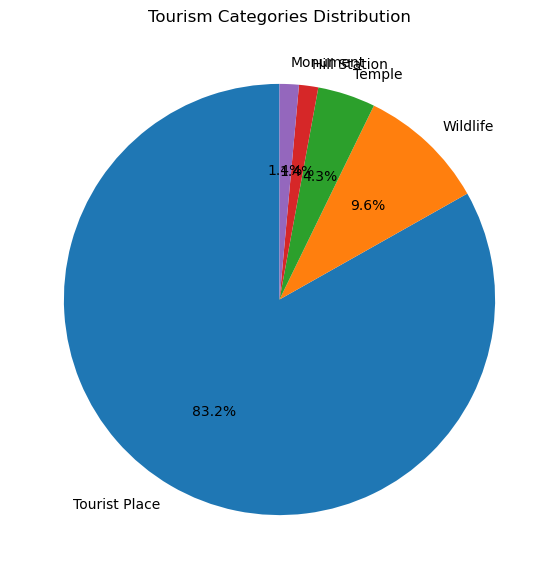

In [196]:
#Tourist Places by Category

plt.figure(figsize=(7,7))

plt.pie(category_counts,
        labels=category_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Tourism Categories Distribution")

plt.show()

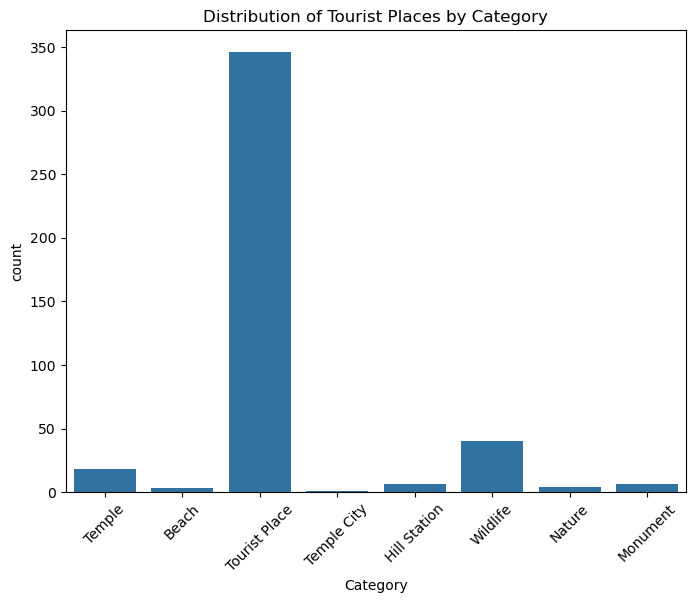

In [187]:
# Tourist Places by Category
plt.figure(figsize=(8,6))
sns.countplot(x="Category", data=df)

plt.title("Distribution of Tourist Places by Category")
plt.xticks(rotation=45)
plt.show()

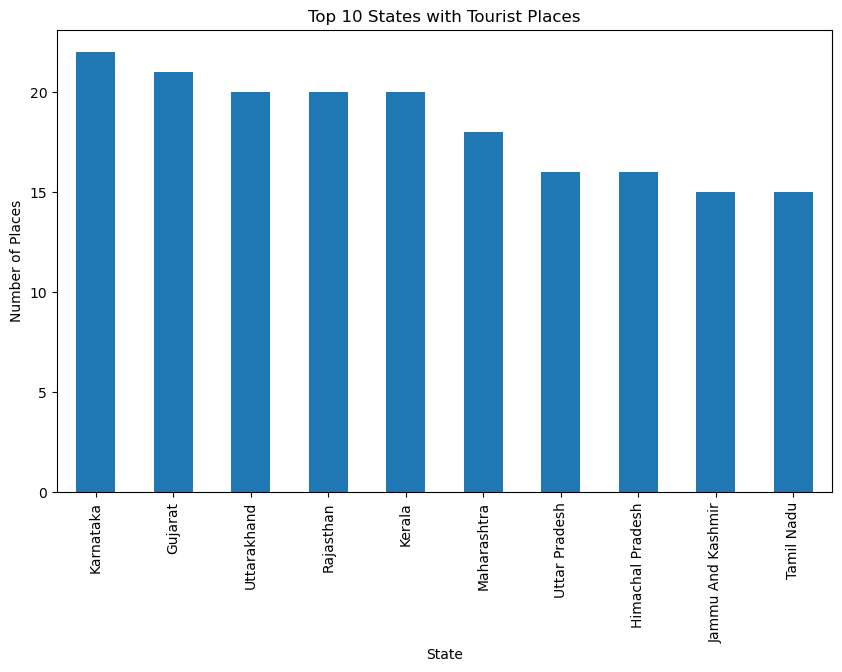

In [188]:
# Tourist Places by State (Top 10)
plt.figure(figsize=(10,6))
df["State"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 States with Tourist Places")
plt.xlabel("State")
plt.ylabel("Number of Places")
plt.show()

# Bi-Variate analysis

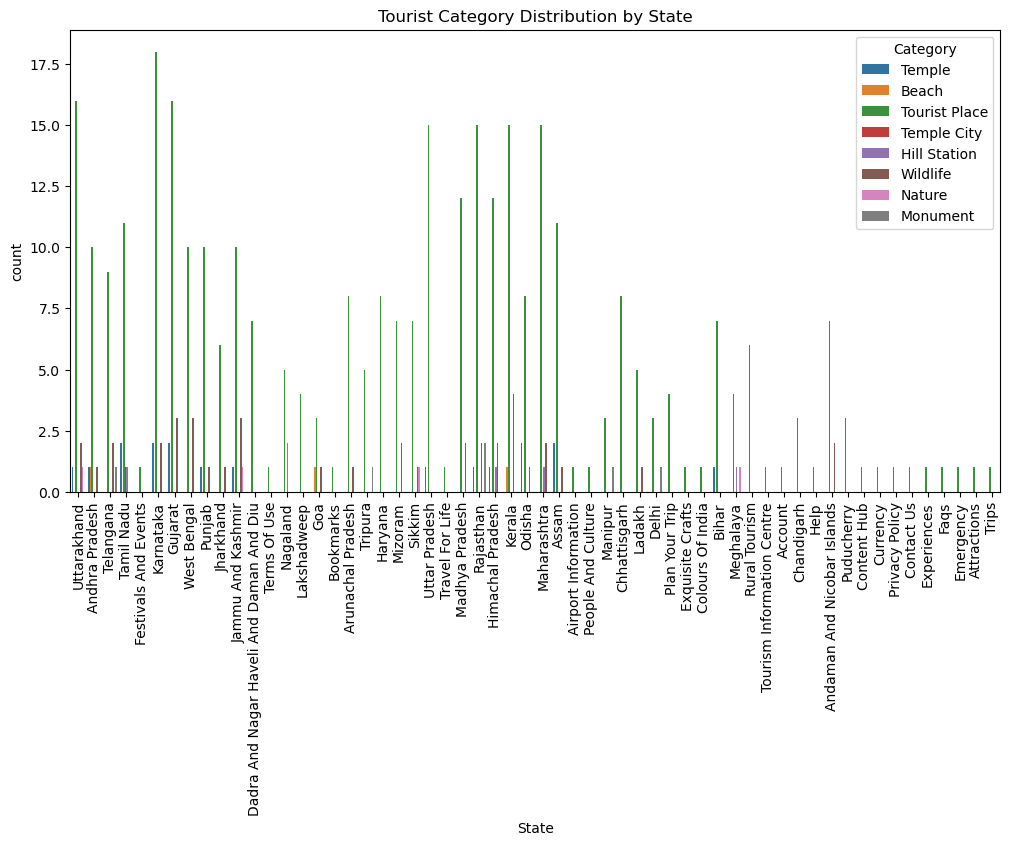

In [190]:
# State vs Category
plt.figure(figsize=(12,6))
sns.countplot(x="State", hue="Category", data=df)

plt.title("Tourist Category Distribution by State")
plt.xticks(rotation=90)
plt.show()

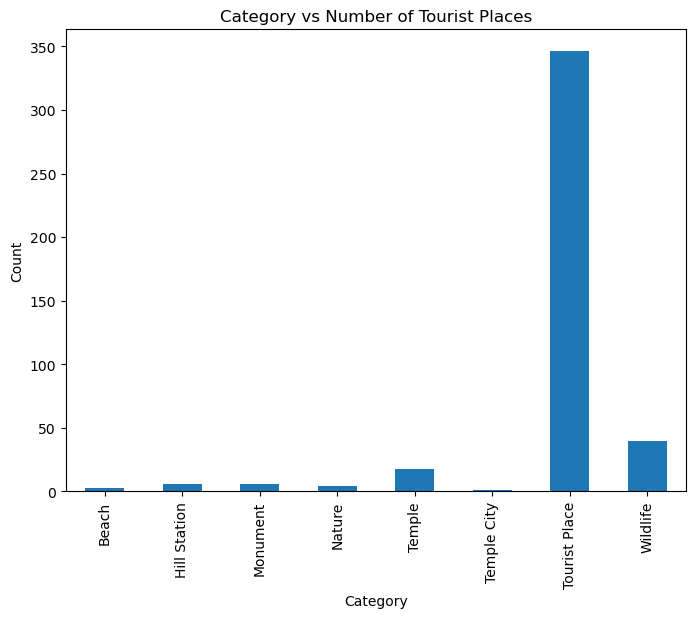

In [193]:
# Category vs Count
category_counts = df.groupby("Category").size()

plt.figure(figsize=(8,6))
category_counts.plot(kind="bar")

plt.title("Category vs Number of Tourist Places")
plt.ylabel("Count")
plt.show()

# Multivariate Analysis

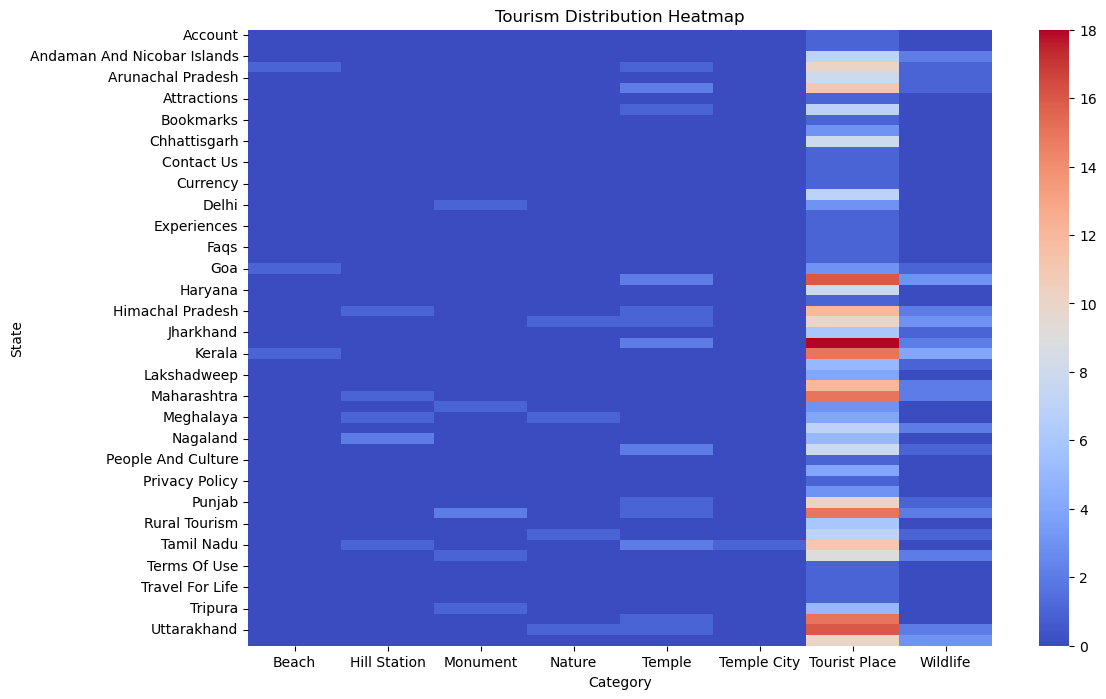

In [197]:
# Multivariate Analysis (3+ Variables)

pivot = pd.crosstab(df["State"], df["Category"])

plt.figure(figsize=(12,8))
sns.heatmap(pivot, cmap="coolwarm")

plt.title("Tourism Distribution Heatmap")
plt.show()

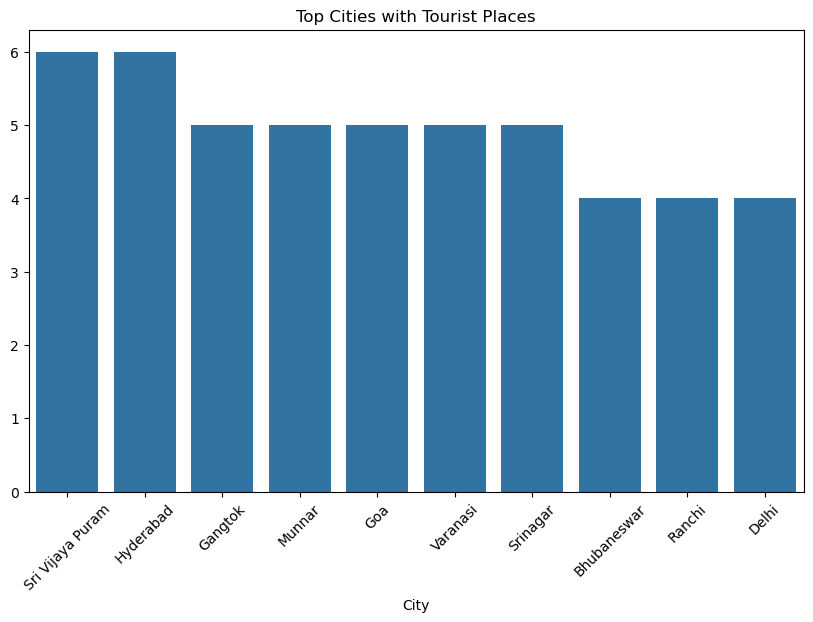

In [200]:
# City Distribution (Top Cities)



top_cities = df["City"].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_cities.index, y=top_cities.values)

plt.title("Top Cities with Tourist Places")
plt.xticks(rotation=45)

plt.show()